```
MODELS:STEP IS ALWAYS SAME FOR LINEAR MODEL
```

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("olympic100m.csv")
df

,year,time
0,1896,12.00
1,1900,11.00
2,1904,11.00
3,1906,11.20
4,1908,10.80
5,1912,10.80
6,1920,10.80
7,1924,10.60
8,1928,10.80
9,1932,10.30


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    29 non-null     int64  
 1   time    29 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 596.0 bytes


In [4]:
df.isna().sum()

year    0
time    0
dtype: int64

In [5]:
x=df[['year']]
x

,year
0,1896
1,1900
2,1904
3,1906
4,1908
5,1912
6,1920
7,1924
8,1928
9,1932


In [6]:
y=df['time']
y

0     12.00
1     11.00
2     11.00
3     11.20
4     10.80
5     10.80
6     10.80
7     10.60
8     10.80
9     10.30
10    10.30
11    10.30
12    10.40
13    10.50
14    10.20
15    10.00
16     9.95
17    10.14
18    10.06
19    10.25
20     9.99
21     9.92
22     9.96
23     9.84
24     9.87
25     9.85
26     9.69
27     9.63
28     9.81
Name: time, dtype: float64

In [7]:
x.shape

(29, 1)

In [8]:
y.shape

(29,)

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=11)

In [10]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(23, 1)
(6, 1)
(23,)
(6,)


In [11]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
ypred=lr.predict(x_test)
ypred

array([10.25514817, 10.7056993 , 10.80582177,  9.70447456, 10.9810361 ,
       10.45539311])

In [13]:
print("co-efficient",lr.coef_)

co-efficient [-0.01251531]


In [14]:
print("intercet",lr.intercept_)

intercet 34.835215399109295


In [15]:
print("MAE:",metrics.mean_absolute_error(y_test,ypred))#error means residual
print("MSE:",metrics.mean_squared_error(y_test,ypred))
print("R2_Score:",metrics.r2_score(y_test,ypred))

MAE: 0.12401703637090389
MSE: 0.024388137535023415
R2_Score: 0.909041911291288


In [16]:
predict=lr.predict([[2028]])
print(predict)

[9.45416838]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:
predict_1=lr.predict([[2032]])
print(predict_1)

[9.40410714]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


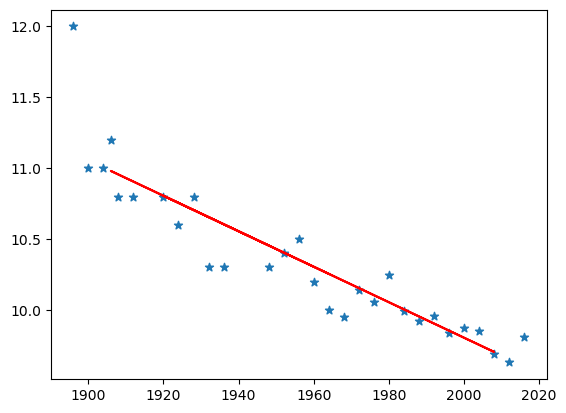

In [18]:
import matplotlib.pyplot as plt
plt.scatter(x,y,marker="*")
plt.plot(x_test,ypred,color='red')
plt.show()

___


# multiple linear regression


In [19]:
df=pd.read_csv("Advertising_03-06.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [20]:
df1=df.drop("Unnamed: 0",axis=1,inplace=True)

In [21]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [23]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [24]:
x=df[["TV","Radio","Newspaper"]]
x.shape

(200, 3)

In [25]:
y=df["Sales"]
y.shape

(200,)

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [27]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [28]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
ypred=lr.predict(x_test)
ypred

array([21.73577184, 16.45693776,  7.65993185, 17.89202679, 18.67730671,
       23.86271904, 16.33623628, 13.45649226,  9.177296  , 17.36056228,
       14.4677995 ,  9.85697601, 17.26057027, 16.71866935, 15.09530285,
       15.58923732, 12.45188167, 17.27925151, 11.0944114 , 18.06889853,
        9.33433055, 12.91345761,  8.7842804 , 10.46670654, 11.40303174,
       15.03104665,  9.78479388, 19.46028647, 18.22954934, 17.1958903 ,
       21.60304218, 14.71901407, 16.29205532, 12.36432281, 19.98831261,
       15.37556411, 13.96678297, 10.06809496, 20.97197274,  7.45877832])

In [30]:
diff=pd.DataFrame({"Actual":y_test,"Prediction":ypred})
diff

,Actual,Prediction
58,23.8,21.735772
40,16.6,16.456938
34,9.5,7.659932
102,14.8,17.892027
184,17.6,18.677307
198,25.5,23.862719
95,16.9,16.336236
4,12.9,13.456492
29,10.5,9.177296
168,17.1,17.360562


In [31]:
print("CO-EFICIENT:",lr.coef_)#VALUE OF COEFICIENT
print("INTERCEPT:",lr.intercept_) #VALUE OF INTERCEPT

CO-EFICIENT: [0.0468431  0.17854434 0.00258619]
INTERCEPT: 2.9079470208164295


In [32]:
print("MAE:",metrics.mean_absolute_error(y_test,ypred))
print("MSE:",metrics.mean_squared_error(y_test,ypred))
print("R2_Score:",metrics.r2_score(y_test,ypred))

MAE: 1.0402154012924718
MSE: 1.9918855518287906
R2_Score: 0.8927605914615384


___

# 2nd Model

In [33]:
df=pd.read_csv("car data_03-06.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [35]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [36]:
df.drop("Car_Name",axis=1,inplace=True)

In [37]:
df

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [38]:
df['Age']=2026-df["Year"]#aane feature engineering kevai
df

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [39]:
df.drop("Year",axis=1,inplace=True)
df

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [40]:
df.isna().sum()

Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
Age              0
dtype: int64

```
aane feature transfering kevai
atle category mathi numeric karvanu
pachi temathi j column ni jarur nathi tene delete kari nakhvi
```

In [46]:
df1=pd.get_dummies(df,drop_first=True)
df1

,Selling_Price,Present_Price,Driven_kms,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,10,True,False,False,True
297,4.00,5.90,60000,0,11,False,True,False,True
298,3.35,11.00,87934,0,17,False,True,False,True
299,11.50,12.50,9000,0,9,True,False,False,True


In [47]:
x=df1.drop("Selling_Price",axis=1)
x.shape

(301, 8)

In [50]:
y=df1["Selling_Price"]
y.shape

(301,)

In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(240, 8)
(61, 8)
(240,)
(61,)


In [59]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
ypred=lr.predict(x_test)
ypred

array([ 7.85988457e+00,  2.96484457e+00, -5.86353170e-01,  4.20732671e+00,
        4.84430668e-01,  5.81347502e+00,  1.95417540e+00,  2.55621488e+00,
        7.70269490e+00,  9.77321182e-01,  8.13346502e+00,  3.50775041e+00,
        4.90111844e+00,  4.63385961e+00, -2.15274140e+00,  3.13946261e+00,
        7.98070078e+00,  6.76005833e+00,  6.90368827e+00,  8.01284011e+00,
        4.30833932e+00,  4.00279074e+00,  1.13044479e+01,  8.07764200e+00,
        9.54920067e+00,  3.51764421e+00,  3.80410358e+00,  1.05969720e+00,
       -6.01614548e-01, -6.16973454e-01,  1.84106334e-03, -1.28129494e+00,
        4.27973440e+00,  2.06795629e+01,  1.87579526e+01,  4.26782531e+00,
        3.48341729e+00,  1.66577514e+00, -4.21151046e-02,  5.78503401e+00,
        8.03148989e+00,  9.88140084e+00,  4.10372630e-01,  6.07970766e+00,
        5.87868397e+00,  4.32270817e+00,  7.37475175e+00,  5.85566283e+00,
        8.20989429e+00,  1.65322947e+00,  3.82591452e+00,  1.74759727e+00,
        2.51206177e+00,  

In [61]:
print("CO-EFICIENT:",lr.coef_)#VALUE OF COEFICIENT
print("INTERCEPT:",lr.intercept_) #VALUE OF INTERCEPT

CO-EFICIENT: [ 4.37218800e-01 -5.35655395e-06  3.45786927e-01 -4.12153677e-01
  2.23319571e+00  4.56283878e-01 -1.20538393e+00 -1.87339339e+00]
INTERCEPT: 7.8894420069358


In [63]:
print("MAE:",metrics.mean_absolute_error(y_test,ypred))#error means residual
print("MSE:",metrics.mean_squared_error(y_test,ypred))
print("R2_Score:",metrics.r2_score(y_test,ypred))

MAE: 1.1064822426372447
MSE: 3.0003727823675543
R2_Score: 0.8616968925961229


In [64]:
x.columns

Index(['Present_Price', 'Driven_kms', 'Owner', 'Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='object')

In [68]:
ypredict=lr.predict([[6.51,38630,0,11,0,1,1,0]])
ypredict
#0=False,1=True for sum data accordingt to columns name 
#always follow sequence columns

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5.24602222])

___

In [69]:
df=pd.read_csv("insurance_03-06.csv")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [72]:
df.drop(["sex","children","region"],axis=1,inplace=True)

In [73]:
df

,age,bmi,smoker,expenses
0,19,27.9,yes,16884.92
1,18,33.8,no,1725.55
2,28,33.0,no,4449.46
3,33,22.7,no,21984.47
4,32,28.9,no,3866.86
...,...,...,...,...
1333,50,31.0,no,10600.55
1334,18,31.9,no,2205.98
1335,18,36.9,no,1629.83
1336,21,25.8,no,2007.95


In [74]:
df1=pd.get_dummies(df,drop_first=True)
df1

,age,bmi,expenses,smoker_yes
0,19,27.9,16884.92,True
1,18,33.8,1725.55,False
2,28,33.0,4449.46,False
3,33,22.7,21984.47,False
4,32,28.9,3866.86,False
...,...,...,...,...
1333,50,31.0,10600.55,False
1334,18,31.9,2205.98,False
1335,18,36.9,1629.83,False
1336,21,25.8,2007.95,False


In [75]:
x=df.drop("expenses",axis=1)
x.shape

(1338, 3)

In [77]:
y=df["expenses"]
y.shape

(1338,)

In [79]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 3)
(268, 3)
(1070,)
(268,)


In [80]:
lr.fit(x_train,y_train)

ValueError: could not convert string to float: 'no'